# Análisis exploratorio cuando lo obvio miente
### Tres escenarios de modelado en seguros y riesgo

**Estadística para IA · Concentración en IA · Tec de Monterrey**
**Mauricio González Soto**


De la **Sesión 1** nos llevamos que $F(x)=P(X\le x)$ contiene *toda* la incertidumbre sobre una variable, y que para decidir bien hace falta la $F$ completa y no uno de sus resúmenes.

De la **Sesión 2** nos llevamos la tesis incómoda: *ningún dato "es" Gamma*. Elegir una familia de distribuciones es firmar un paquete de supuestos, se lea o no, y el error de firmar mal casi nunca es ruido aleatorio, sino que más bien es **exceso sistemático de confianza**.

Vamos a jugar un juego honesto: en cada escenario, un colega les entrega un conjunto de datos. Ustedes actúan como el analista que *no* sabe de dónde vienen. El mecanismo generador real está escrito en una celda que les voy a pedir que corran sin leer todavía. Al final de cada escenario abrimos esa celda y comparamos lo que supusieron contra lo que de verdad pasó.

La pregunta que quiero que se hagan en cada paso es la misma que vimos en clase: **¿de qué proceso surge esto, y qué estoy firmando al modelarlo así?**

Recuerden que si bien todo modelo "está mal", hay de errores a errores

### Cómo usar este Notebk

Van a encontrar tres tipos de cajas:

> **Detente y piensa.** Una pregunta para que respondas *antes* de correr la siguiente celda. No la saltes: casi siempre la gracia está en equivocarse primero.

> **Para discutir en grupo.** Una pregunta abierta, sin respuesta única, para conversar dos o tres minutos.

> **Punto de rigor.** Algo que es técnicamente delicado y que conviene decir con precisión.

Ninguna de las tres trampas de hoy se detecta "mirando el histograma y entrecerrando los ojos". Ese es justamente el punto. Los tres escenarios comparten una moraleja que no voy a adelantar; la reconstruimos juntos al final.


In [5]:
# Todo esto viene por default en Google Colab.
import numpy as np
from scipy import stats, optimize
from scipy.stats import norm
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.2),
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11,
})
TEAL, WARN, GOLD, SLATE = "#169685", "#B03A2E", "#BC8E3A", "#283747"
print("Entorno listo. numpy", np.__version__, "| scipy", stats.__name__)

Matplotlib is building the font cache; this may take a moment.


Entorno listo. numpy 2.5.2 | scipy scipy.stats


In [6]:
# Utilidades que usaremos en los tres escenarios

def ecdf(x):
    xs = np.sort(x)
    ys = np.arange(1, xs.size + 1) / xs.size
    return xs, ys

def hazard_empirico(t, n_bins=15, q_max=0.98):
    "Tasa de riesgo empirica h(t)=fallas/(en riesgo) por unidad de tiempo, por tramos."
    edges = np.unique(np.quantile(t, np.linspace(0, q_max, n_bins)))
    mids, h = [], []
    for a, b in zip(edges[:-1], edges[1:]):
        en_riesgo = np.sum(t >= a)
        fallan = np.sum((t >= a) & (t < b))
        if en_riesgo > 0 and b > a:
            h.append(fallan / en_riesgo / (b - a)); mids.append((a + b) / 2)
    return np.array(mids), np.array(h)

def vida_residual_media(t, ss):
    "E[X - s | X > s] empirico en cada s de ss."
    out = []
    for s in ss:
        m = t[t > s]
        out.append((m - s).mean() if m.size > 30 else np.nan)
    return np.array(out)

def resumen(x, nombre="x"):
    print(f"{nombre}: n={x.size}  media={x.mean():.4g}  "
          f"mediana={np.median(x):.4g}  desv={x.std(ddof=0):.4g}  "
          f"min={x.min():.4g}  max={x.max():.4g}")
    print(f"   coef. de variacion (desv/media) = {x.std(ddof=0)/x.mean():.3f}")
    print(f"   varianza/media = {x.var()/x.mean():.3f}")

# Escenario 1: La cola que no se ve en el histograma

Trabajas en el área de riesgos de una aseguradora. El equipo de reservas necesita responder una pregunta concreta:

> *¿Cuánto capital debemos apartar para cubrir el siniestro individual "malo pero plausible", el que ocurre una vez cada 200 pólizas (percentil 99.5)? ¿Y cuánto esperamos perder, en promedio, cuando se rebasa ese umbral?*

En lenguaje de riesgo, están pidiendo el **VaR al 99.5%** (el cuantil 0.995 de la severidad) y el **Expected Shortfall** (la media condicional más allá de ese cuantil). Un colega te pasa la base de severidades de siniestros pagados del último año. Córrela sin leer el interior.

In [7]:
# ============================================================
# CAJA SELLADA 1. Corre esta celda; no leas el interior todavia.
# (La abrimos juntos al final del escenario.)
# ============================================================
def _generar_severidades(seed=20260819, n=6000):
    rng = np.random.default_rng(seed)
    p_grande = 0.03
    es_grande = rng.random(n) < p_grande
    sev = np.empty(n)
    sev[~es_grande] = rng.lognormal(np.log(15000), 0.9, np.sum(~es_grande))
    sev[es_grande]  = stats.pareto.rvs(b=1.6, scale=180000.0,
                                       size=np.sum(es_grande), random_state=rng)
    return sev

severidad = _generar_severidades()   # pesos mexicanos, un ano de siniestros
print("Recibiste", severidad.size, "severidades de siniestro (MXN).")

Recibiste 6000 severidades de siniestro (MXN).


### 1.1 El primer vistazo

Empieza como empieza cualquiera: mira los datos.

> **Detente y piensa.** Antes de graficar: si te dijeran que esto son montos de siniestros, ¿qué familia de las que vimos esperarías? ¿Qué soporte tiene la cantidad? ¿El mecanismo suena aditivo o multiplicativo?

severidad: n=6000  media=3.516e+04  mediana=1.532e+04  desv=1.62e+05  min=536.1  max=1.007e+07
   coef. de variacion (desv/media) = 4.609
   varianza/media = 746769.853


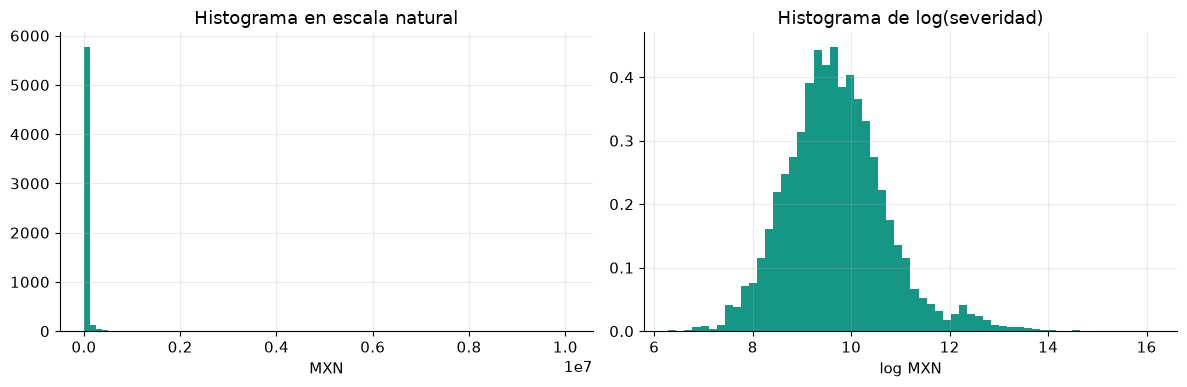

In [8]:
resumen(severidad, "severidad")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(severidad, bins=80, color=TEAL)
ax[0].set_title("Histograma en escala natural"); ax[0].set_xlabel("MXN")
ax[1].hist(np.log(severidad), bins=60, color=TEAL, density=True)
ax[1].set_title("Histograma de log(severidad)"); ax[1].set_xlabel("log MXN")
plt.tight_layout(); plt.show()

El histograma en escala natural es ilegible: casi todo se apila contra el eje y hay un puñado de valores gigantes que estiran el eje horizontal. Es la reacción clásica ante datos positivos y sesgados, así que haces lo que hace todo el mundo: tomas logaritmos. Y en escala logarítmica aparece algo tranquilizador, una campana más o menos simétrica.

La conclusión "natural", la que aparece en el 90% de los reportes, es: *log de los datos se ve normal, entonces los datos son lognormales*. Recuerda la S2P0: la lognormal surge de multiplicar muchos efectos pequeños, y para severidades de siniestros ese mecanismo es perfectamente razonable. Ajustémosla.

Ajuste lognormal:  mu = 9.701   sigma = 1.032


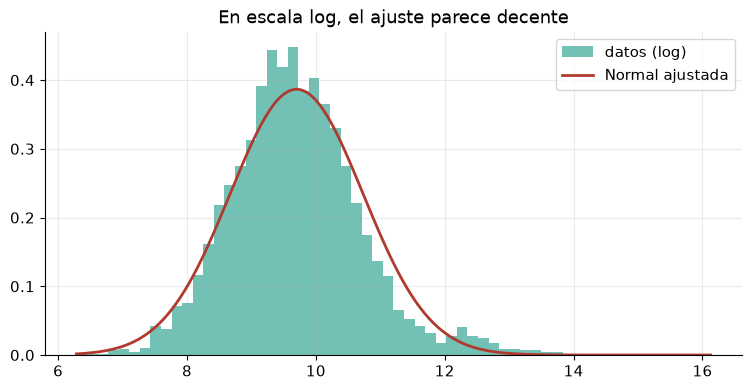

In [9]:
# MLE lognormal: para la lognormal, el estimador de maxima verosimilitud
# es cerrado. mu = media de los logs, sigma = desv. estandar de los logs.
logx = np.log(severidad)
mu_hat, sigma_hat = logx.mean(), logx.std(ddof=0)
print(f"Ajuste lognormal:  mu = {mu_hat:.3f}   sigma = {sigma_hat:.3f}")

xs = np.linspace(logx.min(), logx.max(), 300)
plt.hist(logx, bins=60, density=True, color=TEAL, alpha=0.6, label="datos (log)")
plt.plot(xs, norm.pdf(xs, mu_hat, sigma_hat), color=WARN, lw=2, label="Normal ajustada")
plt.title("En escala log, el ajuste parece decente"); plt.legend(); plt.show()

> **Detente y piensa.** El ajuste no es perfecto: fíjate en el hombro derecho de la campana, donde los datos parecen quedar un poco por encima de la curva roja. ¿Es ese exceso un detalle cosmético que puedes ignorar, o puede cambiar por completo la respuesta a la pregunta de reservas? Anota tu apuesta antes de seguir.

Con el modelo ajustado, contestemos la pregunta de negocio. Bajo la lognormal, el VaR al 99.5% es simplemente el cuantil 0.995 de la distribución ajustada, y lo comparamos con el cuantil empírico de los propios datos.

In [10]:
q = 0.995
var_emp = np.quantile(severidad, q)
var_ln  = stats.lognorm.ppf(q, s=sigma_hat, scale=np.exp(mu_hat))

print(f"VaR 99.5% empirico (de los datos) : {var_emp:>12,.0f} MXN")
print(f"VaR 99.5% segun la lognormal      : {var_ln:>12,.0f} MXN")
print(f"La lognormal reserva {var_emp/var_ln:.2f} veces MENOS de lo que piden los propios datos.")

VaR 99.5% empirico (de los datos) :      566,084 MXN
VaR 99.5% segun la lognormal      :      233,085 MXN
La lognormal reserva 2.43 veces MENOS de lo que piden los propios datos.


Aquí está el primer golpe. El modelo lognormal, que ajustaba "decentemente" el cuerpo de la distribución, recomienda apartar **menos de la mitad** del capital que exigen los datos observados. Y ojo con la dirección del error: no es que a veces reserve de más y a veces de menos. Reserva **sistemáticamente de menos**, justo en la cantidad diseñada para protegerte del desastre.

> **Punto de rigor.** El cuantil empírico al 99.5% con 6000 datos es él mismo ruidoso (se apoya en unas 30 observaciones de la cola). No lo tomes como "la verdad". El punto no es que 566 mil sea el número correcto, sino que la lognormal ni siquiera está en el mismo vecindario. El desacuerdo es estructural, no de precisión.

### 1.2 Las herramientas que sí ven la cola

El histograma nos falló porque la cola pesa poquísimo en frecuencia (son 3 de cada 100 siniestros) pero domina en magnitud. Necesitamos herramientas diseñadas para *mirar la cola*, no el cuerpo. Dos clásicas:

1. **La gráfica de supervivencia en log-log.** Graficamos $P(X>x)$ contra $x$, ambos en escala logarítmica. Una cola tipo *ley de potencia* (Pareto) se ve como una **recta**; una cola lognormal se **curva hacia abajo** y cae más rápido.
2. **La gráfica de exceso medio (mean excess).** Para cada umbral $u$, la media de $(X-u)$ entre los que rebasan $u$. Si esa media **crece** con $u$, la cola es pesada; si se aplana o baja, es ligera.

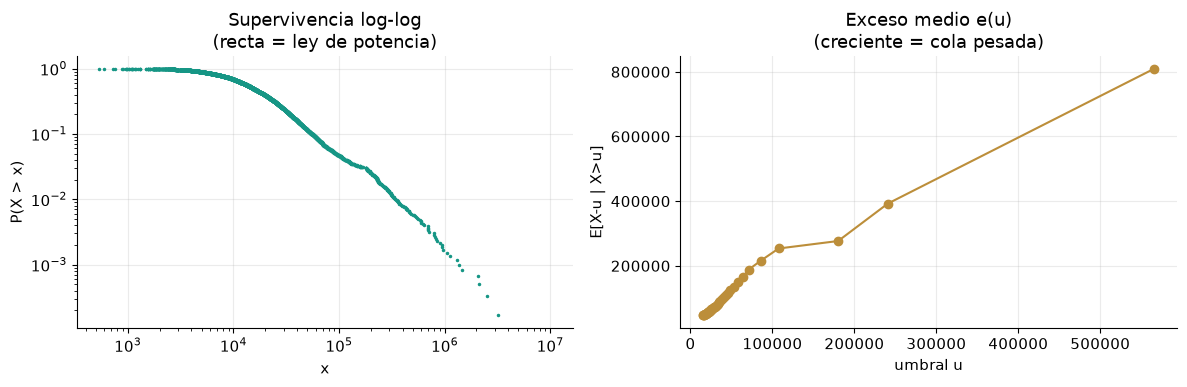

In [11]:
xs_s, ys_s = ecdf(severidad)
surv = 1 - ys_s

# exceso medio e(u) = E[X-u | X>u]
us = np.quantile(severidad, np.linspace(0.5, 0.995, 40))
e_u = np.array([ (severidad[severidad > u] - u).mean() for u in us ])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].loglog(xs_s, surv, '.', ms=3, color=TEAL)
ax[0].set_title("Supervivencia log-log\n(recta = ley de potencia)")
ax[0].set_xlabel("x"); ax[0].set_ylabel("P(X > x)")
ax[1].plot(us, e_u, 'o-', color=GOLD)
ax[1].set_title("Exceso medio e(u)\n(creciente = cola pesada)")
ax[1].set_xlabel("umbral u"); ax[1].set_ylabel("E[X-u | X>u]")
plt.tight_layout(); plt.show()

Las dos gráficas cuentan la misma historia. La supervivencia, tras un cuerpo curvado, se endereza en la cola: eso es firma de ley de potencia. Y el exceso medio, en lugar de aplanarse, **sube** conforme subes el umbral. Traducido: cuanto más grande es un siniestro, *más* margen tiene para ser todavía más grande. Esa es exactamente la propiedad que una lognormal no tiene y que un modelo de cola pesada sí.

Pongámosle número a la cola con el método estándar de la teoría de valores extremos: **Peaks Over Threshold (POT)**. Se fija un umbral alto $u$, se toman los excesos por encima, y se les ajusta una distribución Pareto Generalizada (GPD). El parámetro de forma $\xi$ mide la pesadez: $\xi>0$ es cola tipo potencia; el índice de cola es aproximadamente $1/\xi$.

In [ ]:
u = np.quantile(severidad, 0.90)
excesos = severidad[severidad > u] - u
xi, _, beta = stats.genpareto.fit(excesos, floc=0)
frac_exc = excesos.size / severidad.size

# VaR por POT: u + (beta/xi)*[ ((1-q)/frac_exc)^(-xi) - 1 ]
var_pot = u + (beta/xi) * (((1-q)/frac_exc)**(-xi) - 1)

print(f"GPD sobre excesos (umbral = percentil 90):")
print(f"   xi (forma) = {xi:.3f}   -> indice de cola ~ 1/xi = {1/xi:.2f}")
print(f"   beta (escala) = {beta:,.0f}")
print()
print(f"VaR 99.5% lognormal : {var_ln:>12,.0f} MXN")
print(f"VaR 99.5% empirico  : {var_emp:>12,.0f} MXN")
print(f"VaR 99.5% POT-GPD   : {var_pot:>12,.0f} MXN   ({var_pot/var_ln:.1f}x la lognormal)")

### 1.3 Varias respuestas defendibles, no una sola

Podría parecer que POT es "la respuesta correcta" y ya. Pero la teoría de valores extremos tiene un talón de Aquiles honesto: **el resultado depende del umbral $u$ que elijas** para declarar dónde empieza la cola. Muy bajo, y contaminas la cola con el cuerpo; muy alto, y te quedas con diez datos y varianza enorme. Veámoslo.

In [ ]:
print("Sensibilidad del VaR 99.5% al umbral elegido para la cola:\n")
for up in [0.80, 0.85, 0.90, 0.95]:
    u_ = np.quantile(severidad, up); ex_ = severidad[severidad > u_] - u_
    xi_, _, be_ = stats.genpareto.fit(ex_, floc=0); fe_ = ex_.size/severidad.size
    var_ = u_ + (be_/xi_)*(((1-q)/fe_)**(-xi_) - 1)
    print(f"  umbral = percentil {int(up*100)}   ->  xi={xi_:.3f}   VaR99.5 = {var_:>10,.0f} MXN")
print(f"\n  Referencia lognormal: {var_ln:,.0f} MXN")

Fíjate en lo que ocurre. Según dónde pongas el inicio de la cola, el VaR se mueve entre unos 579 mil y 646 mil pesos. Eso es incertidumbre de modelo **real e irreducible**: dos actuarios cuidadosos, con los mismos datos, pueden reportar cifras que difieren en poco más del 10 por ciento, y ninguno de los dos comete un error de cálculo. Es el eco directo del contraejemplo de Bertrand de la S1: "la cola" no es un objeto único hasta que alguien elige explícitamente cómo definirla.

Pero mira la escala del desacuerdo. La familia de respuestas de cola pesada vive en el rango de 580 a 650 mil. La lognormal vive en 233 mil. El desacuerdo *entre modelos razonables de cola* es de poco más del 10 por ciento; el desacuerdo *entre elegir cola pesada o no* pasa del 150 por ciento. La decisión que de verdad mueve la reserva no es qué umbral, sino que más bien es si reconoces que hay cola pesada.

> **Para discutir en grupo.** Reservar de más también cuesta: es capital inmovilizado que no rinde. Con el lenguaje de teoría de decisión de la S1, ¿cómo escribirías la pérdida de reservar de menos frente a reservar de más? ¿Es simétrica? Si quedarte corto puede quebrar a la aseguradora y quedarte largo solo reduce el rendimiento, ¿qué cuantil de la distribución de severidad deberías usar como reserva, y por qué eso *exige* conocer la $F$ completa y no la media?

### 1.4 Vale la pena preguntarse: la media siquiera existe?

Antes de la revelación, un experimento que conecta con el corazón de lo que comentabamos en las primeras clases. Reserva y VaR se apoyan en cuantiles. Pero muchísimos reportes se apoyan en la **media**. Veamos qué tan confiable es aquí la media muestral, graficando cómo se estabiliza (o no) conforme acumulamos datos.

In [ ]:
orden = np.random.default_rng(0).permutation(severidad.size)
sev_sh = severidad[orden]
media_corr = np.cumsum(sev_sh) / np.arange(1, sev_sh.size + 1)

top1 = np.sort(severidad)[-60:].sum() / severidad.sum()   # 1% mas grande
plt.plot(media_corr, color=SLATE)
plt.axhline(severidad.mean(), color=WARN, ls="--", label="media final")
plt.title("Media corrida: cada escalon es un siniestro enorme entrando")
plt.xlabel("numero de siniestros acumulados"); plt.ylabel("media MXN"); plt.legend(); plt.show()

print(f"El 1% de siniestros mas grandes concentra el {top1:.1%} de TODAS las perdidas.")

> **Punto de rigor.** La media corrida no se asienta con suavidad, sino que da saltos: cada salto es un siniestro gigante que entra y arrastra el promedio. Esto no es mala suerte de la muestra. El ajuste POT de hace un momento estimó un índice de cola alrededor de 1.2, y aunque ese número es sensible al umbral, todos los diagnósticos coinciden en lo esencial: el índice está **por debajo de 2**. Y hay un teorema detrás: para una cola tipo Pareto con índice $\alpha$, la **media existe solo si $\alpha>1$** y la **varianza existe solo si $\alpha>2$**. Estar por debajo de 2 nos deja en la zona incómoda: la media es finita, pero la varianza es **infinita**. Por eso reportar "media más menos dos desviaciones" aquí no es conservador ni agresivo, sino que más bien carece de sentido: la desviación estándar muestral es un número que el estimador escupe, pero que no converge a nada. La S1 nos advirtió que un solo número puede esconder una decisión; este caso es más severo, porque hasta el número que resume la dispersión es una ilusión.

### 1.5 Revelación del Escenario 1

Abramos la caja sellada.

El generador era una **mezcla**: el 97% de los siniestros son "atricionales", una lognormal de mediana 15 mil pesos, el tipo de reclamo cotidiano. Pero el 3% restante son siniestros "grandes", generados por una Pareto con índice 1.6, una cola genuinamente pesada. Ese 3% es invisible en el histograma (se lo traga el cuerpo lognormal), pero es el dueño absoluto del VaR, del Expected Shortfall y de la reserva.

Lo notable es lo que *sí* acertaste y lo que *no*: la intuición "esto es lognormal" no estaba loca, porque el 97% de los datos de verdad son lognormales. El error fue extender ese diagnóstico del cuerpo a la cola, que es donde vivía la pregunta de negocio. Es, palabra por palabra, el caso LTCM de la S1 y la S2P0: colas ligeras supuestas, colas pesadas reales, y una factura que llega justo cuando más duele.

> **Para discutir en grupo.** El mecanismo real era una mezcla de dos poblaciones (atricionales y grandes). Guarda esa palabra, *mezcla*. Vas a volver a tropezar con ella en el Escenario 3, y al final de la clase vamos a sostener que las tres trampas de hoy son, en el fondo, la misma.

# Escenario 2: El tiempo que finge no tener memoria

Cambiamos de producto. Ahora modelas el **tiempo, en años, hasta que una póliza presenta su primer siniestro**. Le interesa a tarificación por una razón muy concreta: si una póliza lleva tres años sin reclamar, ¿cuánto tiempo *adicional* sin siniestro puedes esperar de ella? Esa respuesta entra directo en el precio de renovación.

Un colega te pasa los tiempos hasta el primer siniestro de las pólizas que ya reclamaron. Córrelos sin leer el interior.

In [ ]:
# ============================================================
# CAJA SELLADA 2. Corre esta celda; no leas el interior todavia.
# ============================================================
def _generar_tiempos(seed=7, n=4000):
    rng = np.random.default_rng(seed)
    w_alto = 0.30
    lam_alto, lam_bajo = 2.0, 0.20
    es_alto = rng.random(n) < w_alto
    t = np.where(es_alto,
                 rng.exponential(1/lam_alto, n),
                 rng.exponential(1/lam_bajo, n))
    return t

tiempos = _generar_tiempos()   # anios hasta el primer siniestro
print("Recibiste", tiempos.size, "tiempos hasta primer siniestro (anios).")

### 2.1 El primer vistazo

> **Detente y piensa.** Tiempos de espera hasta un evento. ¿Qué familia salta a la mente por reflejo? ¿Qué estarías firmando con ella, en una frase, según las slides de clase?

In [ ]:
resumen(tiempos, "tiempos")

plt.hist(tiempos, bins=60, density=True, color=TEAL, alpha=0.7, label="datos")
lam_hat = 1/tiempos.mean()
xs = np.linspace(0, tiempos.max(), 300)
plt.plot(xs, lam_hat*np.exp(-lam_hat*xs), color=WARN, lw=2,
         label=f"Exponencial ajustada (lambda={lam_hat:.3f})")
plt.title("Tiempos hasta el primer siniestro"); plt.xlabel("anios"); plt.legend(); plt.show()

El histograma cae de forma monótona desde cero, con una cola larga a la derecha. Es *el* perfil de libro de texto de una exponencial, así que ajustas una exponencial por máxima verosimilitud (que para la exponencial es solo $\hat\lambda = 1/\bar{x}$) y la superpones. Encaja de manera razonable. La exponencial trae, además, un regalo operativo enorme: por su **falta de memoria**, el tiempo adicional esperado sin siniestro es siempre $1/\lambda$, sin importar cuánto lleve ya la póliza. Respuesta directa para tarificación: da igual que la póliza lleve tres años o tres días, el horizonte esperado es el mismo.

Pero ese regalo es justo lo que hay que auditar. La S2P0 fue tajante: usar exponencial y suponer que el sistema no envejece son **la misma decisión**. Antes de cobrarle esa hipótesis al cliente, verifiquémosla.

> **Punto de rigor.** Ya hay una señal de alarma gratis en el resumen de arriba. La exponencial obliga a que el coeficiente de variación (desviación entre media) sea exactamente 1. ¿Cuánto vale en estos datos? Guárdalo; es un detector de mentiras que la propia familia nos regala, igual que la Poisson regala varianza igual a la media.

### 2.2 La herramienta que sí ve la memoria

El histograma no puede ver la falta de memoria, porque la memoria no vive en la forma de la densidad, sino que más bien vive en cómo cambia el riesgo *condicionado a haber sobrevivido*. La herramienta correcta es la **tasa de riesgo (hazard)** de la S2P0:

$$h(t) = \frac{f(t)}{1 - F(t)} = \text{propensión a fallar justo ahora, dado que se sobrevivió hasta } t.$$

La exponencial impone $h(t)$ **plana**. Estimémosla directamente de los datos, sin suponer familia alguna.

In [ ]:
mids, haz = hazard_empirico(tiempos, n_bins=15)

plt.plot(mids, haz, 'o-', color=TEAL, label="hazard empirico")
plt.axhline(lam_hat, color=WARN, ls="--", label=f"exponencial: hazard constante = {lam_hat:.3f}")
plt.title("Tasa de riesgo empirica"); plt.xlabel("anios"); plt.ylabel("h(t)")
plt.legend(); plt.show()

print(f"hazard al inicio ~ {haz[0]:.3f} por ano;  hazard tardio ~ {haz[-1]:.3f} por ano")
print(f"Cae por un factor de ~{haz[0]/haz[-1]:.1f}. La exponencial dice que deberia ser plano.")

El hazard **no es plano en absoluto**: empieza alto y cae por un factor de seis. En cristiano, el riesgo de reclamar es altísimo al principio y va bajando conforme la póliza sobrevive. La exponencial, con su línea horizontal roja, es incapaz de representar esto.

Confirmémoslo con la definición operativa de falta de memoria, la ecuación misma de la S2P0. Comparamos $P(X>s+\Delta \mid X>s)$ para varios valores de $s$, con $\Delta$ fijo. Si el sistema no tuviera memoria, este número sería **constante** en $s$.

In [ ]:
delta = 0.5
print(f"Probabilidad de aguantar {delta} anos MAS, segun cuanto lleve ya sin siniestro:\n")
print(f"{'lleva s anos':>14} | {'P(X>s+0.5 | X>s)':>18} | {'exponencial dice':>17}")
print("-"*56)
const_exp = np.exp(-lam_hat*delta)
for s in [0.0, 1.0, 3.0, 6.0]:
    den = np.sum(tiempos > s)
    if den > 30:
        cond = np.sum(tiempos > s+delta) / den
        print(f"{s:>14.0f} | {cond:>18.3f} | {const_exp:>17.3f}")

La probabilidad de aguantar medio año más **no es constante**: crece de 0.74 a 0.91 conforme la póliza acumula antigüedad sin siniestro. La exponencial insiste en 0.87 para todos. Dicho de otro modo, sobrevivir *es informativo*: una póliza que ya aguantó seis años es un animal distinto de una recién emitida. Eso es precisamente lo contrario de "falta de memoria".

Y ahora la pregunta de negocio, la que entra al precio. La vida residual media, $E[X-s\mid X>s]$: dado que la póliza lleva $s$ años limpia, ¿cuánto más esperamos?

In [ ]:
ss = np.linspace(0, 8, 30)
mrl = vida_residual_media(tiempos, ss)

plt.plot(ss, mrl, 'o-', color=TEAL, label="vida residual media empirica")
plt.axhline(1/lam_hat, color=WARN, ls="--", label=f"exponencial: constante = {1/lam_hat:.2f}")
plt.title("Anios adicionales esperados sin siniestro, dado que sobrevivio s anios")
plt.xlabel("s (anios ya sobrevividos)"); plt.ylabel("anios adicionales esperados")
plt.legend(); plt.show()

s0 = 3.0
rem_true = (tiempos[tiempos > s0] - s0).mean()
print(f"Poliza que ya lleva {s0:.0f} anos sin siniestro:")
print(f"   Exponencial predice   : {1/lam_hat:.2f} anos adicionales")
print(f"   Los datos dicen        : {rem_true:.2f} anos adicionales")
print(f"   La exponencial subestima el horizonte limpio en {(rem_true-1/lam_hat)/rem_true:.0%}.")

El daño es concreto y direccional. Para una póliza con tres años de buen comportamiento, la exponencial predice 3.6 años adicionales sin siniestro; los datos dicen 5.2. La exponencial **subestima cerca de un 30%** el horizonte limpio de tus mejores pólizas, precisamente las que quieres retener. Si tarificas la renovación con el modelo sin memoria, le cobras de más a tus clientes buenos y los empujas a la competencia. La hipótesis de falta de memoria no era un tecnicismo, sino que más bien era una decisión comercial disfrazada de default estadístico.

### 2.3 Dos modelos que arreglan el problema, y no coinciden

Reconocido que el hazard baja, ¿qué familia usamos? Hay al menos dos respuestas defendibles, y la S2P0 nombró ambas como escapes de la falta de memoria.

- Una **Weibull** con parámetro de forma $k<1$ produce hazard decreciente.
- Una **mezcla de dos exponenciales** (dos poblaciones con tasas distintas) también produce hazard decreciente.

Ajustemos las dos y comparémoslas, tanto en su verosimilitud como en la predicción que le importa a negocio.

In [ ]:
# Weibull (scipy: weibull_min con loc=0)
k_w, _, scale_w = stats.weibull_min.fit(tiempos, floc=0)

# Mezcla de 2 exponenciales por EM (Expectation-Maximization)
def em_2exp(x, iters=300):
    w = 0.5
    l1, l2 = 1/np.quantile(x, 0.3), 1/np.quantile(x, 0.8)
    for _ in range(iters):
        f1, f2 = l1*np.exp(-l1*x), l2*np.exp(-l2*x)
        r = w*f1 / (w*f1 + (1-w)*f2 + 1e-300)   # responsabilidad componente 1
        w  = r.mean()
        l1 = r.sum() / (r*x).sum()
        l2 = (1-r).sum() / ((1-r)*x).sum()
    return w, l1, l2

w_e, l1_e, l2_e = em_2exp(tiempos)

def loglik(x, logpdf): return logpdf(x).sum()
ll_exp  = loglik(tiempos, lambda x: np.log(lam_hat) - lam_hat*x)
ll_wei  = stats.weibull_min.logpdf(tiempos, k_w, scale=scale_w).sum()
ll_mix  = np.log(w_e*l1_e*np.exp(-l1_e*tiempos) + (1-w_e)*l2_e*np.exp(-l2_e*tiempos)).sum()

print(f"Exponencial : loglik={ll_exp:>9.1f}  (1 parametro)")
print(f"Weibull     : loglik={ll_wei:>9.1f}  k={k_w:.3f} (<1 => hazard decreciente), escala={scale_w:.2f}")
print(f"Mezcla 2 exp: loglik={ll_mix:>9.1f}  w={w_e:.2f}  tasas=({l1_e:.2f}, {l2_e:.2f})")

Las dos familias mejoran clarísimamente sobre la exponencial (mayor verosimilitud con uno o dos parámetros más), y entre ellas la mezcla gana. Pero la pregunta de negocio no es "cuál tiene mejor verosimilitud", sino qué predice cada una para el horizonte de una póliza que sobrevivió mucho tiempo. Ahí es donde dos modelos igualmente razonables se separan.

In [ ]:
def mrl_teorica_weibull(s, k, scale, hi=200):
    xs = np.linspace(s, s+hi, 20000)
    S = np.exp(-(xs/scale)**k)
    area = np.sum((S[:-1] + S[1:]) / 2 * np.diff(xs))   # regla trapezoidal
    return area / max(S[0], 1e-300)

def mrl_teorica_mezcla(s, w, l1, l2):
    s1, s2 = np.exp(-l1*s), np.exp(-l2*s)
    surv = w*s1 + (1-w)*s2
    return (w*s1/l1 + (1-w)*s2/l2) / surv

print(f"{'s (anos)':>8} | {'Exponencial':>12} | {'Weibull':>9} | {'Mezcla':>8} | {'Empirico':>9}")
print("-"*58)
for s in [0, 3, 6, 9]:
    emp = (tiempos[tiempos > s] - s).mean() if np.sum(tiempos > s) > 30 else np.nan
    print(f"{s:>8} | {1/lam_hat:>12.2f} | {mrl_teorica_weibull(s,k_w,scale_w):>9.2f} | "
          f"{mrl_teorica_mezcla(s,w_e,l1_e,l2_e):>8.2f} | {emp:>9.2f}")

> **Para discutir en grupo.** Weibull y mezcla ajustan casi igual de bien el cuerpo de los datos, pero **extrapolan distinto** el horizonte de las pólizas más longevas. Ninguna de las dos es "la verdad" que puedas leer del histograma. ¿Con cuál tarificarías, y qué información *fuera de estos datos* te ayudaría a decidir? Pista: no la busques en el ajuste, sino que más bien piénsala en el mecanismo. ¿Tiene sentido que existan dos tipos de asegurado, o que el riesgo de cada póliza baje suavemente con el tiempo?

### 2.4 Revelación del Escenario 2

Abramos la caja. El generador **no** era una exponencial, ni una Weibull, ni un mecanismo con desgaste. Era una **mezcla de dos exponenciales**: el 30% de las pólizas son de "alto riesgo" (tasa alta, reclaman pronto) y el 70% de "bajo riesgo" (tasa baja, reclaman tarde o nunca). Nuestra mezcla EM lo recuperó casi exacto: estimó un 32% de alto riesgo contra el 30% real, y tasas de 1.8 y 0.20 contra las 2.0 y 0.20 verdaderas.

Y aquí está lo verdaderamente sutil, que quiero que se lleven grabado: **cada una de las dos subpoblaciones sí carece de memoria** (cada una es exponencial). El hazard decreciente del agregado no viene de que alguna póliza "rejuvenezca", sino que más bien viene de un **efecto de selección**. Al principio observamos la mezcla completa; pero las de alto riesgo reclaman temprano y van saliendo, de modo que las que sobreviven muchos años son, casi con certeza, las de bajo riesgo. La población que queda mejora sola, no porque cada individuo mejore, sino porque los frágiles ya se fueron.

> **Punto de rigor.** Esto conecta con una advertencia que verán toda su carrera: agregar poblaciones heterogéneas puede fabricar propiedades que ningún individuo tiene. La exponencial no fallaba por ser exponencial, sino que más bien fallaba porque le impusimos *una sola tasa* a una población que tenía dos. Vuelve a aparecer la palabra del Escenario 1: **mezcla**. Y con ella, la heterogeneidad no modelada.

# Escenario 3 · Los ceros que son de dos clases distintas

Último escenario, y volvemos a los conteos. Modelas el **número de siniestros por póliza en un año**. Sirve para tarificar: el precio base de una póliza sale, en primera aproximación, de cuántos siniestros esperas de ella.

Un colega te pasa el conteo anual de siniestros de la cartera. Córrelo sin leer el interior.

In [ ]:
# ============================================================
# CAJA SELLADA 3. Corre esta celda; no leas el interior todavia.
# ============================================================
def _generar_conteos(seed=101, n=5000):
    rng = np.random.default_rng(seed)
    pi, lam = 0.62, 0.9
    estructural = rng.random(n) < pi        # nunca reclama
    y = np.where(estructural, 0, rng.poisson(lam, n))
    return y

conteos = _generar_conteos()   # siniestros por poliza en un ano
print("Recibiste", conteos.size, "conteos anuales de siniestros por poliza.")

### 3.1 El primer vistazo

> **Detente y piensa.** Conteos de eventos en un intervalo de tiempo fijo. ¿Cuál es el reflejo? ¿Qué firma, según la S2P0, trae esa familia consigo, esa que funciona como detector de mentiras?

In [ ]:
resumen(conteos, "conteos")
vals, cnt = np.unique(conteos, return_counts=True)
print("\nDistribucion observada:")
for v, c in zip(vals, cnt):
    print(f"   {v} siniestros: {c/conteos.size:6.3f}   ({c} polizas)")

Muchísimos ceros, algunos unos, pocos doses, y una cola corta. Conteos de eventos "raros" por unidad de tiempo: la Poisson es el reflejo entrenado, y la S2P0 lo respalda como el modelo de tasa constante. Su MLE es trivial, $\hat\lambda = \bar{x}$. Ajustémosla y veamos qué tan bien reproduce lo observado.

> **Punto de rigor.** Antes de ajustar, mira el resumen de arriba. La Poisson exige varianza igual a la media. ¿Cuánto vale varianza entre media en estos datos? Si es notablemente mayor que 1, la Poisson ya te avisó, *antes* de ajustar nada, que no es el modelo. Es exactamente la firma que la S2P0 llamó el detector de mentiras incorporado de la Poisson.

In [ ]:
lam_hat = conteos.mean()
kk = np.arange(0, conteos.max()+1)
pois = stats.poisson.pmf(kk, lam_hat)

plt.bar(vals - 0.15, cnt/conteos.size, width=0.3, color=TEAL, label="observado")
plt.bar(kk + 0.15, pois, width=0.3, color=WARN, alpha=0.8, label=f"Poisson (lambda={lam_hat:.3f})")
plt.title("Observado vs Poisson ajustada"); plt.xlabel("siniestros"); plt.legend(); plt.show()

print(f"Varianza/media = {conteos.var()/conteos.mean():.3f}  (Poisson exige 1.0)")
print(f"P(0 siniestros):  observado = {(conteos==0).mean():.3f}   Poisson = {pois[0]:.3f}")
print(f"P(>=1 siniestro): observado = {(conteos>=1).mean():.3f}   Poisson = {1-pois[0]:.3f}")

Dos problemas a la vez. Primero, la varianza es 1.5 veces la media: **sobredispersión**, la violación de la Poisson que en clase comentamos como la más común en datos reales. Segundo, y consecuencia de lo mismo, la Poisson **subestima los ceros** (predice 71% cuando hay 77%) y a cambio **sobreestima los unos**. El modelo reparte mal la masa porque lo obligamos a explicar demasiados ceros subiendo un poco todo lo demás.

> **Punto de rigor.** La dirección del sesgo importa. La Poisson mal especificada cree que hay menos variabilidad de la real, así que sus errores estándar salen artificialmente chicos y sus intervalos, demasiado angostos. En tarificación esto significa declarar "sabemos el riesgo con precisión" cuando no. El error de elegir mal la familia no es ruido, sino que más bien es exceso sistemático de confianza.

### 3.2 Dos arreglos que cuentan historias distintas

Hay dos maneras estándar de absorber la sobredispersión, aparecen en el segundo set de slides. Lo importante es que **no son la misma historia sobre el mundo**.

- **Binomial negativa (NegBin).** La lees como Poisson con tasa incierta: *cada* póliza reclama con su propia tasa $\lambda$, y esas tasas varían de forma continua (una Gamma) a lo largo de la cartera. Todos reclaman; unos con tasa más alta que otros.
- **Poisson inflada en cero (ZIP).** La lees como dos poblaciones **discretas**: una fracción de pólizas son ceros "estructurales" (jamás reclamarían en el periodo, por el tipo de asegurado) y el resto son Poisson ordinarias.

Ajustemos las dos por máxima verosimilitud. Y noten, conectando con la S1 y la S2P0, que "ajustar por máxima verosimilitud" es literalmente minimizar una pérdida, el negativo del log-verosimilitud, que es la misma entropía cruzada que ya optimizan en sus redes.

In [ ]:
# NegBin por optimizacion del NLL (parametrizacion scipy: n=r exitos, p)
def nb_nll(par):
    r, p = par
    if r <= 0 or not (0 < p < 1): return 1e12
    return -stats.nbinom.logpmf(conteos, r, p).sum()
res = optimize.minimize(nb_nll, [1.0, 0.5], method="Nelder-Mead")
r_nb, p_nb = res.x

# ZIP por EM
def em_zip(x, iters=500):
    pi0 = (x == 0).mean() * 0.5
    lam0 = x[x > 0].mean()
    for _ in range(iters):
        pz = pi0 / (pi0 + (1-pi0)*np.exp(-lam0))    # P(cero estructural | x=0)
        z = np.where(x == 0, pz, 0.0)
        pi0 = z.mean()
        w = 1 - z
        lam0 = (w*x).sum() / w.sum()
    return pi0, lam0
pi_z, lam_z = em_zip(conteos)

# log-verosimilitudes y AIC
ll_pois = stats.poisson.logpmf(conteos, lam_hat).sum()
ll_nb   = -res.fun
p0z = pi_z + (1-pi_z)*np.exp(-lam_z)
ll_zip = np.where(conteos == 0, np.log(p0z),
                  np.log(1-pi_z) + stats.poisson.logpmf(np.where(conteos==0,1,conteos), lam_z)).sum()

print(f"{'modelo':<12}{'loglik':>10}{'k':>4}{'AIC':>10}{'P(0) ajustada':>16}")
for nm, ll, k, p0 in [("Poisson", ll_pois, 1, np.exp(-lam_hat)),
                      ("NegBin",  ll_nb,  2, stats.nbinom.pmf(0, r_nb, p_nb)),
                      ("ZIP",     ll_zip, 2, p0z)]:
    print(f"{nm:<12}{ll:>10.1f}{k:>4}{2*k-2*ll:>10.1f}{p0:>16.3f}")
print(f"\nP(0) observada = {(conteos==0).mean():.3f}")
print(f"ZIP estimo: fraccion estructural pi={pi_z:.3f}, tasa de los que si reclaman lam={lam_z:.3f}")

Ambos arreglos capturan los ceros y la sobredispersión mucho mejor que la Poisson (AIC mucho menor), y ambos reproducen $P(0)$ de forma casi indistinguible. Si solo miras el ajuste a la distribución marginal de conteos, **NegBin y ZIP se ven casi idénticos**. Aquí es donde la mayoría de los análisis se detienen, eligen el de mejor AIC y siguen. Ese es el error que quiero exponer.

### 3.3 La misma marginal, decisiones distintas

La pregunta de tarificación no es "¿qué tan bien ajustas la marginal?", sino una pregunta **sobre pólizas individuales**: una póliza que tuvo **cero siniestros este año**, ¿con qué probabilidad reclama el año que viene? De eso depende su descuento por buen historial.

Las tres familias responden distinto, porque cuentan historias distintas sobre qué *significa* un cero.

In [ ]:
# Poisson: anios independientes; un cero no informa nada.
p_pois = 1 - np.exp(-lam_hat)

# NegBin = Poisson-Gamma. Observar un 0 actualiza la Gamma (conjugacion).
# p = beta/(1+beta) => beta = p/(1-p); posterior tras un 0: Gamma(r, beta+1)
beta = p_nb/(1-p_nb)
p_nb_next = 1 - ((beta+1)/(beta+2))**r_nb

# ZIP: el cero pudo ser estructural (nunca reclama) o Poisson-cero.
pz_estructural = pi_z / (pi_z + (1-pi_z)*np.exp(-lam_z))
p_zip_next = (1 - pz_estructural) * (1 - np.exp(-lam_z))

print("P(reclama el proximo ano | 0 siniestros este ano):\n")
print(f"   Poisson : {p_pois:.4f}   (un cero no dice nada; todos iguales)")
print(f"   NegBin  : {p_nb_next:.4f}   (el cero baja un poco su tasa estimada)")
print(f"   ZIP     : {p_zip_next:.4f}   (el cero probablemente es de un 'nunca reclama')")
print(f"\n   Poisson predice {p_pois/p_zip_next:.1f} veces mas riesgo que ZIP para la MISMA poliza.")

Mira la magnitud del desacuerdo. Para exactamente la misma póliza con cero siniestros, la Poisson estima un riesgo de reclamar del 29%, la NegBin del 16% y la ZIP del 13%. La Poisson le cobraría a esa póliza **más del doble** de lo que le cobraría la ZIP. Y ni siquiera NegBin y ZIP, los dos "modelos buenos" que ajustaban casi idéntico la marginal, coinciden: difieren en cerca de un 30%.

La razón es puramente mecanística. Bajo la ZIP, ver un cero es evidencia fuerte de que la póliza pertenece al grupo que *nunca* reclama, así que su riesgo futuro se desploma. Bajo la NegBin, todos reclaman alguna vez, y un cero solo empuja un poco hacia abajo la tasa estimada. Bajo la Poisson, un cero no informa nada porque los años son independientes.

> **Para discutir en grupo.** Los tres modelos "ajustan bien" en el sentido de la distribución marginal, y aun así implican precios distintos para la misma clienta. ¿Cómo decidirías cuál usar? El ajuste marginal no basta, porque los tres pasan esa prueba. La adjudicación tiene que venir de dos lugares que están *fuera* de esta tabla: el **mecanismo** (¿existen de verdad asegurados que estructuralmente jamás reclaman, o todos reclaman a tasas distintas?) y una **prueba predictiva** contra un año de datos que el modelo no vio. Anoten cómo diseñarían esa segunda prueba; tiene nombre, y es la herramienta central de la parte bayesiana del curso.

### 3.4 Revelación del Escenario 3

Abramos la caja. El generador era, en efecto, un mecanismo **inflado en cero**: el 62% de las pólizas eran ceros estructurales que nunca reclaman, y el 38% restante seguía una Poisson de tasa 0.9. Nuestra ZIP lo recuperó bien (estimó 60% estructural y tasa 0.87 contra 62% y 0.90 reales).

Pero lo que quiero subrayar es lo que pasó con la Binomial negativa. La NegBin **no** era el generador y aun así ajustaba la marginal casi tan bien como la ZIP. Con estos datos, y con casi cualquier conjunto real, es muy difícil distinguir "dos grupos discretos" de "un continuo de tasas" mirando solo el histograma de conteos. Son dos modelos que la evidencia marginal apenas separa, y que sin embargo tarifican distinto. El histograma, otra vez, era ciego a la pregunta que de verdad importaba.

# Síntesis · La misma enfermedad con tres disfraces

Hicimos tres escenarios que parecían no tener nada que ver: severidades con cola pesada, tiempos con hazard decreciente, conteos inflados en cero. Quiero cerrar sosteniendo que las tres trampas eran, en el fondo, **el mismo problema**.

En el Escenario 1, la lognormal fallaba porque los datos eran una **mezcla** de atricionales y grandes, y le impusimos una sola familia a dos poblaciones. En el Escenario 2, la exponencial fallaba porque los tiempos eran una **mezcla** de dos clases de riesgo, y le impusimos una sola tasa a una población heterogénea. En el Escenario 3, la Poisson fallaba porque los conteos eran una **mezcla** de "nunca reclama" y Poisson, y le impusimos una sola tasa a dos grupos.

El villano recurrente tiene nombre: **heterogeneidad no modelada**. Y su firma matemática es siempre la misma, la que aparecía en la S2P0 en la identidad de la varianza total. Cuando promedias sobre una heterogeneidad que ignoras, la varianza real es la que tu familia simple predice **más** la varianza de aquello que no modelaste. Por eso los tres modelos ingenuos producían el mismo tipo de error, y no uno cualquiera:

> **El patrón que une a los tres:** elegir la familia demasiado simple no produce errores aleatorios, sino que más bien produce **exceso sistemático de confianza**. La lognormal subreserva. La exponencial subestima el horizonte de las buenas pólizas. La Poisson declara una precisión que no tiene. Ninguno se equivoca al azar; los tres se equivocan hacia el mismo lado, y es el lado peligroso.

Y un patrón metodológico igual de importante, sobre *cómo* los cazamos. En ningún caso el histograma reveló la trampa. Lo que la reveló fue, siempre, una herramienta que miraba **más allá del cuerpo de la distribución**: la cola (supervivencia log-log, exceso medio), el condicionamiento a la supervivencia (hazard, vida residual), o la firma interna de la familia (varianza contra media, coeficiente de variación). Y por encima de cualquier herramienta, pensar el **mecanismo** antes de ajustar.

### Las tres preguntas, revisitadas

La S2P0 proponía tres preguntas antes de escribir el nombre de una familia. Ahora tienen carne:

1. **¿Cuál es el soporte?** Nos habría descartado poco hoy, porque todas las familias candidatas tenían el soporte correcto. El soporte es la criba barata; pasarla no significa nada.
2. **¿Qué mecanismo la genera?** Esta fue *la* pregunta en los tres casos. "¿Hay una o dos poblaciones?" era, cada vez, la bisagra entre el modelo malo y el bueno.
3. **¿Qué tan sorprendentes pueden ser los extremos?** Fue la que más caro se pagó en el Escenario 1, y la que la humanidad más caro ha pagado, con nombre y apellido: LTCM.

> **Para discutir en grupo, para cerrar.** ¿Cuál de las tres trampas de hoy les parece más peligrosa en su propio campo? No la más difícil de detectar, sino la que, de pasarse por alto, costaría más caro. Y una más incómoda: en sus proyectos actuales, ¿qué familia están usando por default, y cuál de sus supuestos no han verificado nunca?

### Hacia dónde vamos...

Ninguna de las soluciones de hoy fue un truco aislado; todas eran la misma idea, y esa idea es la columna vertebral de lo que viene.

- Poner una distribución sobre el parámetro incierto en lugar de fijarlo (la Gamma sobre la tasa de la Poisson, las dos tasas de la mezcla) es el salto a la **estadística bayesiana**.
- Modelar de frente que cada unidad tiene su propio parámetro, con una distribución que los liga, son los **modelos jerárquicos**, la respuesta estructural a la heterogeneidad que hoy solo parcheamos.
- La prueba predictiva que propusieron en el Escenario 3 (simular desde el modelo ajustado y comparar contra datos que no vio) tiene nombre, **posterior predictive check**, y es, en el fondo, el criterio de falsación de Popper aplicado a distribuciones.

Cada trampa de hoy fue una grieta; el resto del curso son las herramientas para cerrarlas de forma principiada, en lugar de a mano.

> **Tercer ingreso al salón de la fama de confusiones.** Tras "la densidad es una probabilidad" (S1) y "mis datos son Normales" (S2), hoy entra: **"mi modelo ajusta bien, entonces es correcto"**. Falso, y no por un tecnicismo. Los tres escenarios tenían modelos que ajustaban bien y decidían mal. Ajustar el cuerpo de una distribución y responder la pregunta de negocio son dos cosas distintas, y confundirlas es la manera más elegante de equivocarse con confianza.

# Apéndice · Extensiones para quien quiera ir más lejos

Ejercicios abiertos, sin solución en el cuaderno, para tarea o para grupos que terminen antes.

1. **Escenario 1, la reserva como decisión.** Formaliza la pérdida asimétrica de reservar (costo $c_u$ por peso de faltante frente a $c_o$ por peso de sobrante) y calcula el fractil crítico óptimo $c_u/(c_u+c_o)$ de la S1. Compara la reserva óptima bajo la lognormal contra la del ajuste POT. ¿La brecha entre modelos importa más o menos conforme el faltante se vuelve más caro que el sobrante?

2. **Escenario 2, censura.** En la realidad no observas el tiempo hasta el siniestro de las pólizas que **aún no** han reclamado; solo sabes que su tiempo es mayor que su antigüedad actual. Eso es *censura por la derecha*, y usar solo las que ya reclamaron sesga todo. Simula una cartera con censura y comprueba cómo cambia el hazard estimado. Es la puerta de entrada al análisis de supervivencia.

3. **Escenario 3, separar NegBin de ZIP.** Diseña la prueba predictiva que discutieron: ajusta ambos modelos con los datos de un año, simula desde cada uno el año siguiente, y compara contra un segundo año real. ¿Qué estadístico (proporción de ceros, proporción de pólizas con dos o más, varianza) separa mejor a los dos modelos? Este es un *posterior predictive check* hecho a mano.

4. **Robustez a la semilla.** Todo el cuaderno usa semillas fijas para que los números sean reproducibles. Cambia las semillas de las tres cajas selladas y vuelve a correr. ¿Las conclusiones cualitativas sobreviven? ¿Cuáles números bailan más, y por qué esos y no otros? Es una forma barata y honesta de medir cuánto de lo que reportaste es señal y cuánto es la muestra particular que te tocó.


*Cierre.* La pregunta con la que abrimos vuelve, ahora con peso: *¿de qué proceso surge esto, y qué estoy firmando al modelarlo así?* En los tres escenarios, la respuesta honesta no vivía en los datos, sino que más bien vivía en el mecanismo que decidimos suponer, y en si nos atrevimos a mirar más allá del cuerpo de la distribución hacia la cola, la memoria y la mezcla, que es donde vivían las preguntas que de verdad importaban.